# Portfolio problem

In [66]:
import math
from pathlib import Path
import cvxpy as cp
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.constants import IN_SAMPLE_TIME_WINDOW, OUT_OF_SAMPLE_TIME_WINDOW
from mis_dro.plot import *

# from matplotlib import rc
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":12})
# rc('text', usetex=True)


In [67]:
# mmc2_dir = Path("/", "Users", "patrick", "Datasets", "misdro", "mmc2")
mmc2_dir = Path("/dcs/pg20/u1508153/datasets/misdro/mmc2")
assert mmc2_dir.exists()
dgp = "DowJones"
returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Assets_Returns", header=None)
index_returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Index_Returns", header=None)

returns_df

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0.007383,0.012783,0.005208,-0.038285,-0.012098,-0.056079,-0.041475,-0.032967,-0.023324,0.010955,...,0.024652,-0.027021,-0.015650,-0.009319,-0.027835,-0.026883,-0.008618,0.006533,0.051115,0.004274
1,0.014659,0.060496,-0.041451,0.014044,0.008151,0.003959,0.014423,0.039771,0.071641,0.014441,...,-0.108267,0.015873,0.023849,0.041915,0.063393,0.050251,-0.043478,0.012988,0.054975,0.046809
2,0.061602,0.028454,0.005405,0.023102,0.010126,0.011830,0.018950,0.016396,0.036207,0.026693,...,0.067451,0.000000,0.017083,0.107200,0.030769,0.040666,0.018176,0.022436,-0.018046,-0.002036
3,0.157034,0.076217,0.021505,0.029342,0.040078,0.052638,-0.037206,-0.013443,0.016138,0.045055,...,-0.037913,0.023438,0.015268,0.048307,0.067165,0.032176,0.000000,-0.018807,0.004088,0.002040
4,-0.002973,-0.042887,-0.036842,-0.019733,-0.013486,0.009256,-0.057971,0.002724,-0.010582,-0.013267,...,-0.013136,-0.041991,0.007514,0.007680,0.006994,0.008909,-0.040180,-0.022364,0.006101,-0.052846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1358,0.053573,0.002948,0.053774,0.014542,0.039465,0.034998,0.064654,0.029174,0.023364,0.020403,...,0.022334,-0.000341,0.023586,-0.037993,0.039939,0.003105,0.061533,0.063085,0.104431,0.026879
1359,0.006381,0.041936,-0.024272,0.008619,-0.000660,-0.023225,-0.013680,0.006321,-0.007807,0.029084,...,0.028417,0.049082,0.007722,0.026329,0.027990,-0.000929,0.009661,-0.021790,-0.027284,0.021828
1360,0.033067,0.012977,0.014683,-0.003530,0.027090,0.026488,0.022666,0.017130,0.009056,0.008390,...,0.012139,0.007404,0.018726,0.064299,0.075352,0.024166,0.027531,0.020063,0.043448,0.028452
1361,-0.006798,-0.005941,0.007175,0.008855,0.012866,-0.008401,-0.017532,-0.000749,0.002207,0.002847,...,0.017201,-0.005169,0.008736,-0.052225,-0.033638,-0.002622,-0.015194,-0.005885,-0.007511,0.001896


In [68]:
experiment_dir = Path("/dcs/large/u1508153/misdro/tiny_kl_portfolio")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
# NOTE filter out when log_partition_constant G is less than epsilon
# results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]
results_df

mean_cost  var_cost  \
uuid                                 replication                        
0476020a-667a-475b-a036-b29598feac4d 0             0.024998  0.003980   
                                     1             0.013439  0.004527   
                                     2             0.008790  0.002081   
                                     3             0.028088  0.001964   
                                     4            -0.000823  0.004172   
...                                                     ...       ...   
7285942c-2e6c-4202-90cd-ef954c3c7643 104           0.001850  0.000181   
                                     105          -0.001846  0.000148   
                                     106          -0.006454  0.001083   
                                     107           0.007614  0.000345   
                                     108           0.001181  0.000585   

                                                                                           solution  \
uuid                                 replication                                                      
0476020a-667a-475b-a036-b29598feac4d 0            [4.920768005677304e-09, 1.2473459949010729e-08...   
                                     1            [3.864726353855574e-10, 1.07412133958714e-09, ...   
                                     2            [5.246939999016289e-10, 6.237876722974108e-09,...   
                                     3            [8.944718516637793e-10, 6.991143101482353e-10,...   
                                     4            [2.8936057316513235e-09, 2.860761718169876e-08...   
...                                                                                             ...   
7285942c-2e6c-4202-90cd-ef954c3c7643 104          [0.029068639119373865, 0.033090720270550704, 0...   
                                     105          [0.03321572386396494, 0.03784287429925622, 0.0...   
                                     106          [0.034883829806971065, 0.03802987248164945, 0....   
                                     107          [0.03835493921990218, 0.039472708957769706, 0....   
                                     108          [0.03383348485676907, 0.02641816095251582, 0.0...   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
0476020a-667a-475b-a036-b29598feac4d 0            0.603697         0.000003   
                                     1            0.271133         0.000001   
                                     2            0.273292         0.000001   
                                     3            0.402401         0.000001   
                                     4            0.273060         0.000002   
...                                                    ...              ...   
7285942c-2e6c-4202-90cd-ef954c3c7643 104          0.236875         0.000001   
                                     105          0.237246         0.000001   
                                     106          0.280858         0.000001   
                                     107          0.237442         0.000002   
                                     108          0.236583         0.000001   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
0476020a-667a-475b-a036-b29598feac4d 0                  0.000896    0.036744   
                                     1                  0.000517    0.012598   
                                     2                  0.000458    0.012788   
                                     3                  0.000416    0.011825   
                                     4                  0.000427    0.011952   
...                                                          ...         ...   
7285942c-2e6c-4202-90cd-ef954c3c7643 104                0.002103    0.116097   
            

In [69]:
agg_df = get_agg_df(results_df, ["algorithm","dgp", "epsilon", "num_posterior_samples"])
agg_df

/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:287: FutureWarning: The provided callable <function mean at 0x7f85880fe520> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:287: FutureWarning: The provided callable <function var at 0x7f85880fe7a0> is currently using SeriesGroupBy.var. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "var" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:287: FutureWarning: The provided callable <function mean at 0x7f85880fe520> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis

out_of_sample_mean  \
algorithm  dgp      epsilon num_posterior_samples                       
kl_bdro    DowJones 0.00001 5                                0.006779   
                            10                               0.006766   
                            30                               0.006804   
                    0.00002 5                                0.006551   
                            10                               0.006505   
...                                                               ...   
kl_dro_bas DowJones 0.05000 1                                0.002581   
                    0.10000 1                                0.002504   
                    0.20000 1                                0.002458   
                    0.50000 1                                0.002420   
                    1.00000 1                                0.002401   

                                                   out_of_sample_mean_of_vars  \
algorithm  dgp      epsilon num_posterior_samples                               
kl_bdro    DowJones 0.00001 5                                        0.002369   
                            10                                       0.002370   
                            30                                       0.002369   
                    0.00002 5                                        0.002262   
                            10                                       0.002275   
...                                                                       ...   
kl_dro_bas DowJones 0.05000 1                                        0.000486   
                    0.10000 1                                        0.000473   
                    0.20000 1                                        0.000467   
                    0.50000 1                                        0.000464   
                    1.00000 1                                        0.000463   

                                                   out_of_sample_var_of_means  \
algorithm  dgp      epsilon num_posterior_samples                               
kl_bdro    DowJones 0.00001 5                                        0.000185   
                            10                                       0.000184   
                            30                                       0.000184   
                    0.00002 5                                        0.000170   
                            10                                       0.000169   
...                                                                       ...   
kl_dro_bas DowJones 0.05000 1                                        0.000030   
                    0.10000 1                                        0.000029   
                    0.20000 1                                        0.000028   
                    0.50000 1                                        0.000028   
                    1.00000 1                                        0.000028   

                                                   mean_solve_time  \
algorithm  dgp      epsilon num_posterior_samples                    
kl_bdro    DowJones 0.00001 5                             0.033282   
                            10                            0.055830   
                            30                            0.127442   
                    0.00002 5                             0.032720   
                            10                            0.053553   
...                                                            ...   
kl_dro_bas DowJones 0.05000 1                             0.011771   
                    0.10000 1                             0.011766   
                    0.20000 1                             0.012064   
                    0.50000 1                             0.011824   
                    1.00000 1                             0.012099   

                                                   std_solve_time  \
algorithm  dg

/tmp/dcs-tmp.u1508153/ipykernel_736507/2878663845.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "is_maximise_pareto_front"] = is_maximise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)


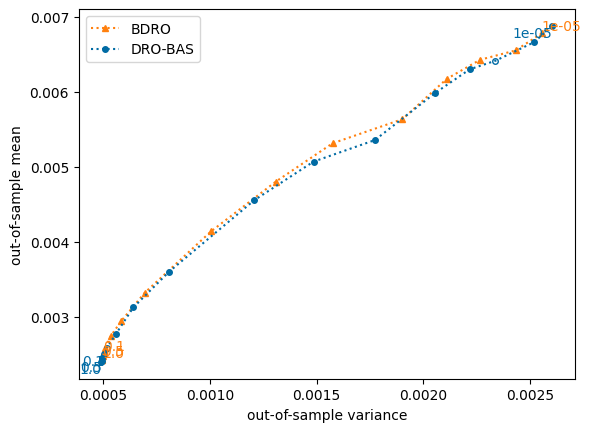

In [80]:
posterior_sr = agg_df.index.get_level_values("num_posterior_samples")
fig, ax = plt.subplots()
NUM_POSTERIOR_SAMPLES = 5
df = agg_df.loc[(posterior_sr == 1) | (posterior_sr == NUM_POSTERIOR_SAMPLES)]
# df = df.loc[:,:,0.1:]
df.loc[:, "is_maximise_pareto_front"] = is_maximise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
gb = df.groupby("algorithm")
for algorithm, group_df in gb:
    mean_variance_plot(ax, group_df, is_labelled=True, offset=0, alpha=1.0, **algorithm_style(algorithm), pareto_front_col="is_maximise_pareto_front")
ax.legend()
ax.set_xlabel("out-of-sample variance")
ax.set_ylabel("out-of-sample mean")
fig.show()

In [71]:
num_time_windows = math.floor((len(returns_df) - IN_SAMPLE_TIME_WINDOW) / OUT_OF_SAMPLE_TIME_WINDOW)
num_stocks = int(len(returns_df.columns))

In [72]:
week_cols = [f"week_{i}" for i in range(OUT_OF_SAMPLE_TIME_WINDOW)]
stock_cols = [f"stock_{i}" for i in range(num_stocks)]
dro_returns = {week: [] for week in week_cols}
for stock in stock_cols:
    dro_returns[stock] = []
dro_returns["uuid"] = []
dro_returns["replication"] = []
for idx, row in results_df[["out_of_sample_costs", "solution"]].iterrows():
    uuid, replication = idx
    str_cost, str_solution = row["out_of_sample_costs"], row["solution"]
    if str_cost == "[]":
        costs = [np.nan for _ in range(OUT_OF_SAMPLE_TIME_WINDOW)]
    else:
        costs = [float(x) for x in str_cost.strip('[]').split(',')]
    solution = [float(x) for x in str_solution.strip('[]').split(',')]
    dro_returns["uuid"].append(uuid)
    dro_returns["replication"].append(replication)
    for i, week in enumerate(week_cols):
        dro_returns[week].append(costs[i])
    for i, stock in enumerate(stock_cols):
        dro_returns[stock].append(solution[i])

dro_returns_df = pd.DataFrame(dro_returns).set_index(["uuid", "replication"])
dro_returns_df

week_0    week_1  \
uuid                                 replication                           
0476020a-667a-475b-a036-b29598feac4d 0           -1.594972e-09 -0.050020   
                                     1            6.729545e-02  0.054776   
                                     2           -2.443281e-02  0.037209   
                                     3            3.172795e-02  0.030805   
                                     4            8.446712e-02 -0.055225   
...                                                        ...       ...   
7285942c-2e6c-4202-90cd-ef954c3c7643 104          1.004530e-02 -0.024601   
                                     105          3.353291e-03  0.002414   
                                     106          1.746858e-02  0.006104   
                                     107          5.013240e-02  0.022048   
                                     108          1.565050e-02 -0.020830   

                                                    week_2    week_3  \
uuid                                 replication                       
0476020a-667a-475b-a036-b29598feac4d 0           -0.024254  0.157638   
                                     1            0.012966 -0.094854   
                                     2            0.095895 -0.008184   
                                     3           -0.009944 -0.046255   
                                     4            0.077950 -0.015310   
...                                                    ...       ...   
7285942c-2e6c-4202-90cd-ef954c3c7643 104          0.019098  0.020901   
                                     105          0.003636 -0.000711   
                                     106         -0.033347  0.011191   
                                     107          0.003935  0.027694   
                                     108         -0.040300 -0.022044   

                                                    week_4    week_5  \
uuid                                 replication                       
0476020a-667a-475b-a036-b29598feac4d 0            0.103964  0.006483   
                                     1            0.084995 -0.049596   
                                     2           -0.038401 -0.014521   
                                     3            0.033755  0.040802   
                                     4           -0.158193  0.077187   
...                                                    ...       ...   
7285942c-2e6c-4202-90cd-ef954c3c7643 104          0.003546  0.010515   
                                     105          0.009960 -0.005193   
                                     106          0.002419 -0.001859   
                                     107          0.011800 -0.008530   
                                     108         -0.003623  0.032221   

                                                    week_6    week_7  \
uuid                                 replication                       
0476020a-667a-475b-a036-b29598feac4d 0            0.048394  0.052304   
                                     1            0.046698 -0.013102   
                                     2            0.046551 -0.088960   
                                     3            0.074491 -0.001822   
                                     4           -0.032698  0.030588   
...                                                    ...       ...   
7285942c-2e6c-4202-90cd-ef954c3c7643 104         -0.017283 -0.003405   
                                     105         -0.008713 -0.019479   
                                     106         -0.094569  0.039118   
                                     107         -0.012478  0.018067   
                                     108         -0.022434  0.001246   

                                                    week_8    week_9  ...  \
uuid                                 replication                      ...   
0476020a-667a-475b-a036-b29598feac4d 0           -0.026274 -0.036055  ...   
                         

In [73]:
# join the dataframes, the sort and groupby
results_df = results_df.join(dro_returns_df)
results_df

mean_cost  var_cost  \
uuid                                 replication                        
0476020a-667a-475b-a036-b29598feac4d 0             0.024998  0.003980   
                                     1             0.013439  0.004527   
                                     2             0.008790  0.002081   
                                     3             0.028088  0.001964   
                                     4            -0.000823  0.004172   
...                                                     ...       ...   
7285942c-2e6c-4202-90cd-ef954c3c7643 104           0.001850  0.000181   
                                     105          -0.001846  0.000148   
                                     106          -0.006454  0.001083   
                                     107           0.007614  0.000345   
                                     108           0.001181  0.000585   

                                                                                           solution  \
uuid                                 replication                                                      
0476020a-667a-475b-a036-b29598feac4d 0            [4.920768005677304e-09, 1.2473459949010729e-08...   
                                     1            [3.864726353855574e-10, 1.07412133958714e-09, ...   
                                     2            [5.246939999016289e-10, 6.237876722974108e-09,...   
                                     3            [8.944718516637793e-10, 6.991143101482353e-10,...   
                                     4            [2.8936057316513235e-09, 2.860761718169876e-08...   
...                                                                                             ...   
7285942c-2e6c-4202-90cd-ef954c3c7643 104          [0.029068639119373865, 0.033090720270550704, 0...   
                                     105          [0.03321572386396494, 0.03784287429925622, 0.0...   
                                     106          [0.034883829806971065, 0.03802987248164945, 0....   
                                     107          [0.03835493921990218, 0.039472708957769706, 0....   
                                     108          [0.03383348485676907, 0.02641816095251582, 0.0...   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
0476020a-667a-475b-a036-b29598feac4d 0            0.603697         0.000003   
                                     1            0.271133         0.000001   
                                     2            0.273292         0.000001   
                                     3            0.402401         0.000001   
                                     4            0.273060         0.000002   
...                                                    ...              ...   
7285942c-2e6c-4202-90cd-ef954c3c7643 104          0.236875         0.000001   
                                     105          0.237246         0.000001   
                                     106          0.280858         0.000001   
                                     107          0.237442         0.000002   
                                     108          0.236583         0.000001   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
0476020a-667a-475b-a036-b29598feac4d 0                  0.000896    0.036744   
                                     1                  0.000517    0.012598   
                                     2                  0.000458    0.012788   
                                     3                  0.000416    0.011825   
                                     4                  0.000427    0.011952   
...                                                          ...         ...   
7285942c-2e6c-4202-90cd-ef954c3c7643 104                0.002103    0.116097   
            

In [74]:
results_df = results_df.loc[(results_df["num_posterior_samples"] == NUM_POSTERIOR_SAMPLES) | (results_df["num_posterior_samples"] == 1)]
gb = results_df.groupby(["algorithm", "epsilon", "num_posterior_samples"])

In [75]:
for (algorithm, epsilon, num_posterior_samples), group_df in gb:
    dro_bas_returns = group_df[week_cols].values.flatten()
    print(algorithm, epsilon, np.sum(dro_bas_returns))

kl_bdro 1e-05 8.866358844946024
kl_bdro 2e-05 8.569284504476371
kl_bdro 5e-05 8.40675438531757
kl_bdro 0.0001 8.07287433665415
kl_bdro 0.0002 7.370910628686474
kl_bdro 0.0005 6.951109227038294
kl_bdro 0.001 6.28453956824054
kl_bdro 0.002 5.41862338076875
kl_bdro 0.005 4.346897410750964
kl_bdro 0.01 3.8572254816906137
kl_bdro 0.02 3.5937913541215614
kl_bdro 0.05 3.378711421084964
kl_bdro 0.1 3.2978189232151345
kl_bdro 0.2 3.245586737265806
kl_bdro 0.5 3.200389493765016
kl_bdro 1.0 3.180472201182198
kl_dro_bas 1e-05 8.996574947272702
kl_dro_bas 2e-05 8.712979007341813
kl_dro_bas 5e-05 8.390338884577183
kl_dro_bas 0.0001 8.239196166256342
kl_dro_bas 0.0002 7.822233936513717
kl_dro_bas 0.0005 7.007202640452834
kl_dro_bas 0.001 6.631363998944469
kl_dro_bas 0.002 5.960766888259301
kl_dro_bas 0.005 4.714574389828746
kl_dro_bas 0.01 4.090150346959352
kl_dro_bas 0.02 3.6296396302567246
kl_dro_bas 0.05 3.3754548186116033
kl_dro_bas 0.1 3.2750966461680227
kl_dro_bas 0.2 3.2144129554983794
kl_dro_

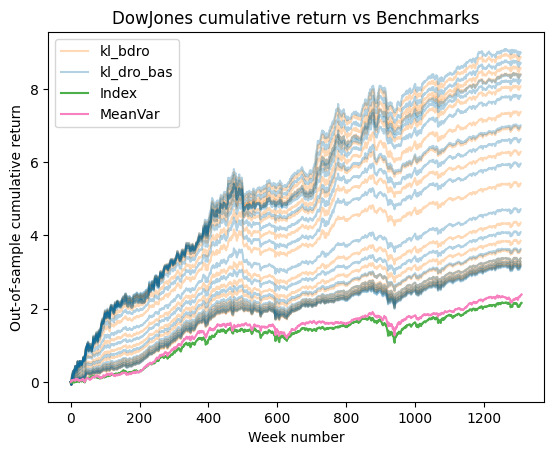

In [76]:
# dro_bas_returns = solution_returns.flatten()
bdro_labelled = False
dro_bas_labelled = False
for (algorithm, epsilon, num_posterior_samples), group_df in gb:
    dro_returns = group_df[week_cols].values.flatten()
    if not dro_bas_labelled and algorithm == "kl_dro_bas":
        label = algorithm
        dro_bas_labelled = True
    elif not bdro_labelled and algorithm == "kl_bdro":
        label = algorithm
        bdro_labelled = True
    else:
        label='_nolegend_'
    plt.plot(np.cumsum(dro_returns), label=label, alpha=0.3, color=AlgorithmColor[algorithm].value)
CB_color_cycle = ['#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
plt.plot(np.cumsum(index_returns_df.iloc[IN_SAMPLE_TIME_WINDOW:].values), label="Index", color=CB_color_cycle[0])
# for baseline_model in ["CZeSD", "KP_SSD", "L_SSD", "LR_ASSD", "MeanVar", "RMZ_SSD"]:

for i, baseline_model in enumerate(["MeanVar"]):
    baseline_portfolio_txt = mmc2_dir / "Solutions" / dgp / f"OptPortfolios_{baseline_model}_{dgp}.txt"
    baseline_portfolio = np.loadtxt(baseline_portfolio_txt).T[:num_time_windows, :]
    baseline_returns_txt = mmc2_dir / "Solutions" / dgp / f"OutofSamplePortReturns_{baseline_model}_{dgp}_List.txt" 
    baseline_returns = np.loadtxt(baseline_returns_txt)
    plt.plot(np.cumsum(baseline_returns), label=baseline_model, color=CB_color_cycle[i+1])

plt.xlabel("Week number")
plt.ylabel("Out-of-sample cumulative return")
plt.title(dgp + r" cumulative return vs Benchmarks")
plt.legend()
plt.show()

In [77]:

for (algorithm, epsilon), group_df in results_df.groupby(["algorithm", "epsilon"]):
    # print(algorithm, epsilon, np.mean(group_df[stock_cols].values), np.var(group_df[stock_cols].values))
    print(algorithm, epsilon, np.mean(group_df[stock_cols].values, axis=0))

kl_bdro 1e-05 [3.01433360e-01 2.06802667e-02 3.28212674e-08 6.11082820e-08
 3.00590431e-08 3.58302792e-08 2.90550023e-02 3.30492475e-08
 9.17515367e-03 2.87396504e-08 1.78873093e-02 4.62303910e-06
 2.64128314e-02 1.17934967e-03 8.82202744e-02 1.45772678e-02
 4.68522061e-03 1.61897604e-01 1.58335120e-01 1.69277430e-02
 2.02201361e-03 4.09109930e-02 3.52465344e-02 3.97322888e-08
 2.42374711e-02 4.21578461e-08 4.35620468e-02 3.54950768e-03]
kl_bdro 2e-05 [2.97329680e-01 2.18456729e-02 3.22922689e-08 1.62311964e-07
 3.71200003e-08 5.88349875e-08 2.88060197e-02 3.79641020e-08
 1.02665960e-02 3.33907894e-08 1.67461880e-02 9.50759965e-04
 2.54309078e-02 2.10587831e-03 8.76036156e-02 1.52708408e-02
 5.53591147e-03 1.62483092e-01 1.54301243e-01 2.07521705e-02
 2.50531954e-03 4.06407690e-02 3.43755422e-02 3.64156027e-08
 2.50133923e-02 6.87359280e-08 4.31084313e-02 4.92749854e-03]
kl_bdro 5e-05 [2.83138113e-01 2.49060378e-02 7.76474367e-08 8.76531928e-04
 3.98184225e-06 1.70207329e-03 2.62182219